In [2]:
import json
from pathlib import Path

filepath = Path("wandb_encoders/autointent_encoders2/results.json")

with filepath.open("r") as f:
    data = json.load(f)

len(data)

25

In [3]:
metric_name = "decision_accuracy"

In [4]:
def transform_record(rec):
    rec["metrics"] = rec["metrics"][metric_name]
    return rec

In [5]:
import pandas as pd

df = pd.DataFrame([transform_record(rec) for rec in data])
df.head()

,dataset,encoder,metrics
0,DeepPavlov/clinc150,intfloat/multilingual-e5-large,0.787091
1,DeepPavlov/clinc150,intfloat/multilingual-e5-large-instruct,0.789818
2,DeepPavlov/clinc150,HIT-TMG/KaLM-embedding-multilingual-mini-v1,0.788545
3,DeepPavlov/clinc150,NovaSearch/stella_en_400M_v5,0.918000
4,DeepPavlov/clinc150,nomic-ai/nomic-embed-text-v1.5,0.755273


In [6]:
df_new = pd.pivot_table(df, values="metrics", columns="dataset", index="encoder")
df_new.reset_index(inplace=True)
df_new

dataset,encoder,DeepPavlov/clinc150,DeepPavlov/hwu64,DeepPavlov/massive,DeepPavlov/minds14,DeepPavlov/snips
0,HIT-TMG/KaLM-embedding-multilingual-mini-v1,0.788545,0.886617,0.835916,0.953704,0.974286
1,NovaSearch/stella_en_400M_v5,0.918000,0.921933,0.892183,0.962963,0.985000
2,intfloat/multilingual-e5-large,0.787091,0.913569,0.874663,0.925926,0.983571
3,intfloat/multilingual-e5-large-instruct,0.789818,0.909851,0.871294,0.981481,0.983571
4,nomic-ai/nomic-embed-text-v1.5,0.755273,0.838290,0.806941,0.972222,0.973571


In [7]:
df_new["average"] = df_new.drop(columns=["encoder"]).mean(axis=1)
df_new

dataset,encoder,DeepPavlov/clinc150,DeepPavlov/hwu64,DeepPavlov/massive,DeepPavlov/minds14,DeepPavlov/snips,average
0,HIT-TMG/KaLM-embedding-multilingual-mini-v1,0.788545,0.886617,0.835916,0.953704,0.974286,0.887814
1,NovaSearch/stella_en_400M_v5,0.918000,0.921933,0.892183,0.962963,0.985000,0.936016
2,intfloat/multilingual-e5-large,0.787091,0.913569,0.874663,0.925926,0.983571,0.896964
3,intfloat/multilingual-e5-large-instruct,0.789818,0.909851,0.871294,0.981481,0.983571,0.907203
4,nomic-ai/nomic-embed-text-v1.5,0.755273,0.838290,0.806941,0.972222,0.973571,0.869259


In [8]:
df_new.sort_values(by="average", ascending=False)

dataset,encoder,DeepPavlov/clinc150,DeepPavlov/hwu64,DeepPavlov/massive,DeepPavlov/minds14,DeepPavlov/snips,average
1,NovaSearch/stella_en_400M_v5,0.918000,0.921933,0.892183,0.962963,0.985000,0.936016
3,intfloat/multilingual-e5-large-instruct,0.789818,0.909851,0.871294,0.981481,0.983571,0.907203
2,intfloat/multilingual-e5-large,0.787091,0.913569,0.874663,0.925926,0.983571,0.896964
0,HIT-TMG/KaLM-embedding-multilingual-mini-v1,0.788545,0.886617,0.835916,0.953704,0.974286,0.887814
4,nomic-ai/nomic-embed-text-v1.5,0.755273,0.838290,0.806941,0.972222,0.973571,0.869259


In [9]:
df_new = df_new.apply(lambda x: x * 100 if x.dtype == float else x)
df_new

dataset,encoder,DeepPavlov/clinc150,DeepPavlov/hwu64,DeepPavlov/massive,DeepPavlov/minds14,DeepPavlov/snips,average
0,HIT-TMG/KaLM-embedding-multilingual-mini-v1,78.854545,88.661710,83.591644,95.370370,97.428571,88.781368
1,NovaSearch/stella_en_400M_v5,91.800000,92.193309,89.218329,96.296296,98.500000,93.601587
2,intfloat/multilingual-e5-large,78.709091,91.356877,87.466307,92.592593,98.357143,89.696402
3,intfloat/multilingual-e5-large-instruct,78.981818,90.985130,87.129380,98.148148,98.357143,90.720324
4,nomic-ai/nomic-embed-text-v1.5,75.527273,83.828996,80.694070,97.222222,97.357143,86.925941


In [10]:
pd.set_option("display.precision", 2)

In [12]:
print(df_new.sort_values(by="average", ascending=False).to_string(index=False))

                                    encoder  DeepPavlov/clinc150  DeepPavlov/hwu64  DeepPavlov/massive  DeepPavlov/minds14  DeepPavlov/snips  average
               NovaSearch/stella_en_400M_v5                91.80             92.19               89.22               96.30             98.50    93.60
    intfloat/multilingual-e5-large-instruct                78.98             90.99               87.13               98.15             98.36    90.72
             intfloat/multilingual-e5-large                78.71             91.36               87.47               92.59             98.36    89.70
HIT-TMG/KaLM-embedding-multilingual-mini-v1                78.85             88.66               83.59               95.37             97.43    88.78
             nomic-ai/nomic-embed-text-v1.5                75.53             83.83               80.69               97.22             97.36    86.93


## дубль два

In [4]:
import pandas as pd

precise = pd.read_csv("retrieval_different_retrievals_full_accuracy.csv")
precise

,model,DeepPavlov/hwu64,DeepPavlov/massive,DeepPavlov/minds14,DeepPavlov/snips,mean
0,NovaSearch/stella_en_400M_v5,0.921933,0.892183,0.972222,0.985000,0.942835
1,intfloat/multilingual-e5-large-instruct,0.909851,0.871294,0.981481,0.983571,0.936550
2,avsolatorio/GIST-large-Embedding-v0,0.907993,0.875337,0.972222,0.985000,0.935138
3,WhereIsAI/UAE-Large-V1,0.908922,0.870957,0.953704,0.982143,0.928931
4,BAAI/bge-m3,0.907063,0.867588,0.944444,0.988571,0.926917
5,intfloat/multilingual-e5-large,0.890335,0.841644,0.944444,0.980000,0.914106
6,sentence-transformers/LaBSE,0.883829,0.842655,0.916667,0.975714,0.904716
7,HIT-TMG/KaLM-embedding-multilingual-mini-instr...,0.878253,0.833895,0.962963,0.910714,0.896456
8,nomic-ai/nomic-embed-text-v1.5,0.797398,0.775606,0.953704,0.962857,0.872391
9,microsoft/deberta-v3-small,0.769517,0.766509,0.731481,0.978571,0.811520


In [5]:
proxy = pd.read_csv("retrieval_different_retrievals_full_config_ndcg.csv")
proxy

,model_name,DeepPavlov/hwu64,DeepPavlov/massive,DeepPavlov/minds14,DeepPavlov/snips,mean
0,NovaSearch/stella_en_400M_v5,0.919358,0.885599,0.966228,0.981939,0.938281
1,avsolatorio/GIST-large-Embedding-v0,0.910536,0.881765,0.967485,0.973086,0.933218
2,WhereIsAI/UAE-Large-V1,0.911237,0.880007,0.965696,0.973242,0.932546
3,intfloat/multilingual-e5-large-instruct,0.907317,0.866620,0.967013,0.977896,0.929711
4,HIT-TMG/KaLM-embedding-multilingual-mini-instr...,0.894532,0.863566,0.994013,0.963079,0.928798
5,BAAI/bge-m3,0.893559,0.872077,0.959130,0.974755,0.924881
6,intfloat/multilingual-e5-large,0.886730,0.862128,0.973712,0.975429,0.924499
7,nomic-ai/nomic-embed-text-v1.5,0.843296,0.823832,0.963636,0.954477,0.896310
8,sentence-transformers/LaBSE,0.862593,0.846405,0.887190,0.984052,0.895060
9,microsoft/deberta-v3-small,0.584066,0.603931,0.574219,0.925888,0.672026


In [79]:
pd.set_option("display.precision", 2)

In [80]:
precise_ = precise[["model", "mean"]].rename({"model": "model_name"}, axis=1)
precise_
proxy_ = proxy[["model_name", "mean"]]
merged = pd.merge(left=precise_, right=proxy_, on="model_name")
merged[["mean_x", "mean_y"]] *= 100
merged

,model_name,mean_x,mean_y
0,NovaSearch/stella_en_400M_v5,94.28,93.83
1,intfloat/multilingual-e5-large-instruct,93.65,92.97
2,avsolatorio/GIST-large-Embedding-v0,93.51,93.32
3,WhereIsAI/UAE-Large-V1,92.89,93.25
4,BAAI/bge-m3,92.69,92.49
5,intfloat/multilingual-e5-large,91.41,92.45
6,sentence-transformers/LaBSE,90.47,89.51
7,HIT-TMG/KaLM-embedding-multilingual-mini-instr...,89.65,92.88
8,nomic-ai/nomic-embed-text-v1.5,87.24,89.63
9,microsoft/deberta-v3-small,81.15,67.20


In [82]:
print(merged.to_string(index=False))

                                            model_name  mean_x  mean_y
                          NovaSearch/stella_en_400M_v5   94.28   93.83
               intfloat/multilingual-e5-large-instruct   93.65   92.97
                   avsolatorio/GIST-large-Embedding-v0   93.51   93.32
                                WhereIsAI/UAE-Large-V1   92.89   93.25
                                           BAAI/bge-m3   92.69   92.49
                        intfloat/multilingual-e5-large   91.41   92.45
                           sentence-transformers/LaBSE   90.47   89.51
HIT-TMG/KaLM-embedding-multilingual-mini-instruct-v1.5   89.65   92.88
                        nomic-ai/nomic-embed-text-v1.5   87.24   89.63
                            microsoft/deberta-v3-small   81.15   67.20
                            microsoft/deberta-v3-large   75.39   59.59
                             microsoft/deberta-v3-base   75.00   59.28


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_parallel_rankings(precise, approximate, title="Parallel Rankings Comparison"):
    """
    Plot a parallel coordinates-style plot to compare two rankings.
    
    Parameters:
        precise (list): Ground truth ranking (list of item labels in order).
        approximate (list): Approximate ranking (same items, possibly different order).
        title (str): Title of the plot.
    """
    if sorted(precise) != sorted(approximate):
        raise ValueError("Both rankings must contain the same items.")

    # Create a mapping from item to rank (0-based)
    precise_rank = {item: i for i, item in enumerate(precise)}
    approximate_rank = {item: i for i, item in enumerate(approximate)}

    items = precise
    y1 = [precise_rank[item] for item in items]
    y2 = [approximate_rank[item] for item in items]

    fig, ax = plt.subplots(figsize=(2, 6))
    for i, item in enumerate(items):
        annotation = item.split("/")[1][:20]
        ax.plot([0, 1], [y1[i], y2[i]], marker='o', label=annotation, alpha=0.7)
        ax.text(-0.1, y1[i], annotation, ha='right', va='center')
        ax.text(1.1, y2[i], annotation, ha='left', va='center')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Precise', 'Approximate'])
    ax.set_yticks(range(len(items)))
    ax.invert_yaxis()
    # ax.grid(True, axis='y', linestyle='--', alpha=0.85)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    return fig


In [92]:
models = precise.sort_values(by="mean", ascending=False)["model"].to_list()
models

['NovaSearch/stella_en_400M_v5',
 'intfloat/multilingual-e5-large-instruct',
 'avsolatorio/GIST-large-Embedding-v0',
 'WhereIsAI/UAE-Large-V1',
 'BAAI/bge-m3',
 'intfloat/multilingual-e5-large',
 'sentence-transformers/LaBSE',
 'HIT-TMG/KaLM-embedding-multilingual-mini-instruct-v1.5',
 'nomic-ai/nomic-embed-text-v1.5',
 'microsoft/deberta-v3-small',
 'microsoft/deberta-v3-large',
 'microsoft/deberta-v3-base']

In [93]:
models_2 = proxy.sort_values(by="mean", ascending=False)["model_name"].to_list()
models_2

['NovaSearch/stella_en_400M_v5',
 'avsolatorio/GIST-large-Embedding-v0',
 'WhereIsAI/UAE-Large-V1',
 'intfloat/multilingual-e5-large-instruct',
 'HIT-TMG/KaLM-embedding-multilingual-mini-instruct-v1.5',
 'BAAI/bge-m3',
 'intfloat/multilingual-e5-large',
 'nomic-ai/nomic-embed-text-v1.5',
 'sentence-transformers/LaBSE',
 'microsoft/deberta-v3-small',
 'microsoft/deberta-v3-large',
 'microsoft/deberta-v3-base']

/tmp/ipykernel_39637/3428597564.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


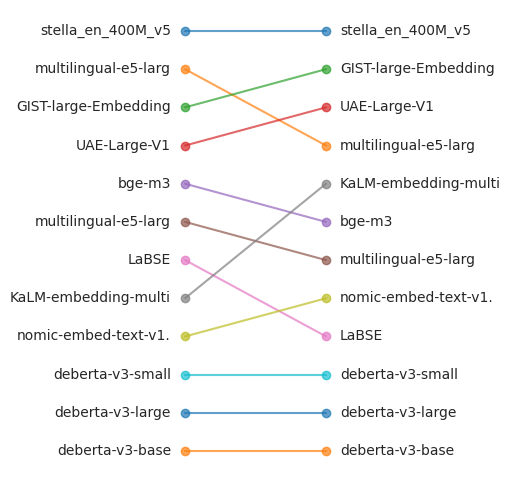

In [95]:
fig = plot_parallel_rankings(models, models_2)

In [97]:
fig.savefig("par.pdf", bbox_inches="tight")